#### Unzip WhatsApp Chats

In [ ]:
import zipfile
import os

source_dir = "/Users/pariidan/Documents/python_projects/RAG_Langchain/data/zipped_chats"
output_dir = "/Users/pariidan/Documents/python_projects/RAG_Langchain/data/whatsapp_chats"


In [185]:
for file_name in os.listdir(source_dir):
    if file_name.endswith('.zip'):
        file_path = source_dir + '/' + file_name

        print(f'Extracting {file_name}..')
        with zipfile.ZipFile(file_path,'r') as zip_object:

            for file_info in zip_object.filelist:
                new_name = file_name.replace('.zip','')
                file_info.filename = new_name + '.txt'

                zip_object.extract(file_info,output_dir)

#### Structure Text Data

In [186]:
import re
## In this method I will go through each chat, and through each message from the chat, I will tags in form of keys
## Specificall : 1) ChatId, 2)Sender, 3) Day, 4) Time

def parse_message(line):
    """Extract from message specfic content"""
    pattern = r'\[(\d{2}\.\d{2}\.\d{4}), (\d{2}:\d{2}:\d{2})\] ~? ?([^:]*(?::[^: ])*[^:]*): (.*)'
    

    match = re.match(pattern,line)
    
    if match:
        return {'date' : match.group(1),
                'time': match.group(2),
                'sender': match.group(3),
                'content': match.group(4)}
    return None

def split_chat(chat_text):
    """Split WhatsApp chat by message timestamps, preserving multiline messages"""
    # Pattern to match the timestamp at start of message
    pattern = r'(?=\[\d{2}\.\d{2}\.\d{4}, \d{2}:\d{2}:\d{2}\])'
    # Split by the pattern and filter out empty strings
    messages = [msg.strip() for msg in re.split(pattern, chat_text) if msg.strip()]
    
    return messages

def parse_chat(chat,chat_id,chat_name):
    chat_lines = chat.split('\n')
    chat_lines = split_chat(chat)
    message_dicts = []

    for line in chat_lines:
        message_dict = parse_message(line)
        if message_dict:

            message_dict['chat_id'] = chat_id
            message_dict['chat_name'] = chat_name
            message_dicts.append(message_dict)
        else:
            print(f'Line "{line}" from {chat_name} is not a valid message format')

    return message_dicts


In [ ]:
import os

source_dir = "/Users/pariidan/Documents/python_projects/RAG_Langchain/data/whatsapp_chats"
all_messages = []
chat_id = 0

for file_name in os.listdir(source_dir):

    if file_name.startswith('Whats'):
        file_path = source_dir + '/' + file_name
        with open(file_path,'r') as file:
            text = file.read()

            chat_name = file_name.replace('WhatsApp Chat - ','').replace('.txt','')
            chat_messages = parse_chat(text,chat_id,chat_name)            
            chat_id+=1

            all_messages.extend(chat_messages)

#### Process Structured Data

In [188]:
import pandas as pd

chat_df = pd.DataFrame(all_messages)
chat_df.head()

Before defining chunks, let's also add some informative elements that will be useful per chunk (i.e besides the actual messages)

- ChunkId : chat_id+date
- Date: date
- Participants : Dan (Me),  {list of senders besides Dan}
- Language : English or Romanian
- Number of Messages

#### Binary Language Classification

In [189]:
from transformers import pipeline

classifier = pipeline("text-classification", 
                     model="qanastek/51-languages-classifier",
                     truncation=True,
                     max_length=512)


In [ ]:
from tqdm import tqdm
tqdm.pandas()  # Enable pandas progress tracking

language_map = {
    'ro-RO': 'ro',
    'en-US': 'en',

}

def classify_language(text):
    res = classifier(text)[0]
    if res['score'] > 0.5:
        label = language_map.get(res['label'],res['label'])
        return label
    else:
        return 'unknown(possibly slang)'

chat_df['language'] = chat_df['content'].progress_apply(classify_language)
chat_df['chat_language'] = chat_df.groupby('chat_id')['language'].transform(lambda x: x.mode().iloc[0])

In [1]:
import pandas as pd
chat_df = pd.read_csv('/Users/pariidan/Documents/python_projects/RAG_Langchain/data/processed_data/whatsapp_chats.csv',index_col=0)

In [22]:
# determine chat type
chat_df['is_groupchat'] = chat_df['chat_id'].map(chat_df.groupby('chat_id')['sender'].nunique()>2) 

In [23]:
# determine people sending messages
chat_df['participants'] = chat_df.groupby('chat_id')['sender'].transform(lambda x: [list(x.unique())] * len(x))

In [24]:
# fix issue with group name added as participant
def remove_gc_participant(row):
    if row['is_groupchat']:
        return row['participants'][1:]
    else:
        return row['participants']

chat_df['participants'] = chat_df.apply(remove_gc_participant, axis=1)

In [ ]:
### Replace names that I did not save (originally phone numbers)
def process_chat_name(row):
    if row['is_groupchat']:
        return row['chat_name']
    else:
        names = [name for name in row['participants'] if name!='Dan']
        return names[0]
chat_df['chat_name'] = chat_df.apply(process_chat_name, axis=1)

In [ ]:
## Make me the main user
chat_df.loc[chat_df['sender']=='Dan','sender'] = 'Me'

#### Determine Chunking Strategy

In [10]:
chat_df['content'] = chat_df['content'].apply(str)
chat_df['content_len'] = chat_df['content'].apply(len)
chat_lens = chat_df.groupby('chat_id')['content_len'].sum()
chat_df['long_chat'] = chat_df['chat_id'].map(chat_lens > 3000)

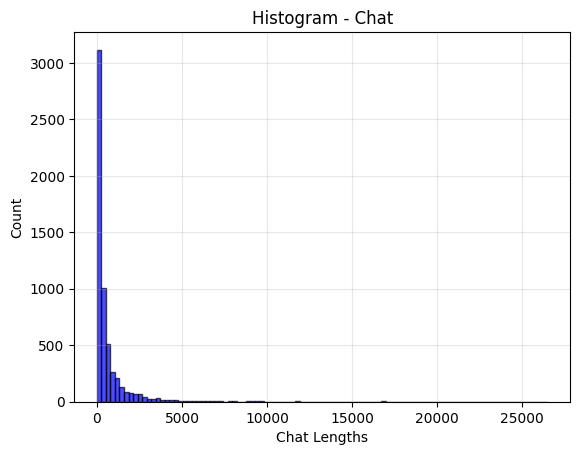

In [32]:
chat_lens = chat_df[chat_df['long_chat']].groupby(['date','chat_name'])['content_len'].sum()
import matplotlib.pyplot as plt
import numpy as np

# Quick histogram

plt.hist(chat_lens.values,bins=100, alpha=0.7, color='blue', edgecolor='black')
plt.xlabel('Chat Lengths')
plt.ylabel('Count')
plt.title('Histogram - Chat')
plt.grid(True, alpha=0.3)
plt.show()

In [33]:
import pandas as pd
chat_df['date'] = pd.to_datetime(chat_df['date'], format='%d.%m.%Y').dt.date

#### Build Chunks - Strategy Split By Time Unit

In [22]:
def chunk_messages(full_df, chunk_size=5000):
    """Chunk WhatsApp messages using hierarchical strategy: chat -> month -> week -> day -> equal parts"""
    chunks = []
    
    for chat_id in full_df['chat_id'].unique():
        df = full_df[full_df['chat_id'] == chat_id].copy()
        df['date'] = pd.to_datetime(df['date'])
        df['year_month'] = df['date'].dt.to_period('M')
        df['year_week'] = df['date'].dt.to_period('W')
        
        base_metadata = {
            'chat_id': chat_id,
            'chat_name': df['chat_name'].iloc[0],
            'is_groupchat': df['is_groupchat'].iloc[0],
            'chat_language': df['chat_language'].iloc[0],
            'participants': df['participants'].iloc[0],
        }
        
        # Level 1: Try whole chat
        chat_text = '\n'.join(df.apply(lambda row: f"{row['sender']}: {row['content']}", axis=1))
        if len(chat_text) < chunk_size:
            chunks.append({
                'chunk_text': chat_text,
                'date_range': f"{df['date'].min().date()} - {df['date'].max().date()}",
                'chunk_type': 'full_chat',
                'part': 'full',
                'messages_count': len(df),
                **base_metadata
            })
        else:
            # Level 2: Split by month
            for month, month_group in df.groupby('year_month'):
                month_text = '\n'.join(month_group.apply(lambda row: f"{row['sender']}: {row['content']}", axis=1))
                if len(month_text) < chunk_size:
                    chunks.append({
                        'chunk_text': month_text,
                        'date_range': f"{month_group['date'].min().date()} - {month_group['date'].max().date()}",
                        'chunk_type': 'monthly',
                        'part': 'full',
                        'messages_count': len(month_group),
                        **base_metadata
                    })
                else:
                    # Level 3: Split by week
                    for week, week_group in month_group.groupby('year_week'):
                        week_text = '\n'.join(week_group.apply(lambda row: f"{row['sender']}: {row['content']}", axis=1))
                        if len(week_text) < chunk_size:
                            chunks.append({
                                'chunk_text': week_text,
                                'date_range': f"{week_group['date'].min().date()} - {week_group['date'].max().date()}",
                                'chunk_type': 'weekly',
                                'part': 'full',
                                'messages_count': len(week_group),
                                **base_metadata
                            })
                        else:
                            # Level 4: Split by day
                            for date, day_group in week_group.groupby(week_group['date'].dt.date):
                                day_text = '\n'.join(day_group.apply(lambda row: f"{row['sender']}: {row['content']}", axis=1))
                                if len(day_text) < chunk_size:
                                    chunks.append({
                                        'chunk_text': day_text,
                                        'date_range': str(date),
                                        'chunk_type': 'daily',
                                        'part': 'full',
                                        'messages_count': len(day_group),
                                        **base_metadata
                                    })
                                else:
                                    # Level 5: Split into equal parts
                                    for i in range(0, len(day_text), chunk_size):
                                        sub_chunk = day_text[i:i+chunk_size]
                                        chunk_proportion = len(sub_chunk) / len(day_text)
                                        estimated_message_count = max(1, round(len(day_group) * chunk_proportion))
                                        chunks.append({
                                            'chunk_text': sub_chunk,
                                            'date_range': str(date),
                                            'chunk_type': 'sub_daily',
                                            'part': i//chunk_size + 1,
                                            'messages_count': estimated_message_count,
                                            **base_metadata
                                        })
    return chunks
    

In [ ]:
# save final messages
chat_df.to_csv("/Users/pariidan/Documents/python_projects/RAG_Langchain/data/processed_data/whatsapp_chats.csv")

#### Build Chunks - Strategy Split By Size First, Time Later

In [11]:
def chunk_messages(full_df, chunk_size=5000):
    chunks = []
    
    for chat_id in full_df['chat_id'].unique():
        df = full_df[full_df['chat_id'] == chat_id].copy()
        df = df.sort_values('date')  # Ensure chronological order
        
        base_metadata = {
            'chat_id': chat_id,
            'chat_name': df['chat_name'].iloc[0],
            'is_groupchat': df['is_groupchat'].iloc[0],
            'chat_language': df['chat_language'].iloc[0],
            'participants': df['participants'].iloc[0],
        }
        
        current_chunk = ""
        current_messages = []
        
        for _, row in df.iterrows():
            message = f"{row['sender']}: {row['content']}\n"
            
            # If adding this message exceeds chunk_size, finalize current chunk
            if len(current_chunk + message) > chunk_size and current_chunk:
                chunks.append({
                    'chunk_text': current_chunk.strip(),
                    'date_range': f"{current_messages[0]['date']} - {current_messages[-1]['date']}",
                    'chunk_type': 'size_based',
                    'part': len([c for c in chunks if c['chat_id'] == chat_id]) + 1,
                    'messages_count': len(current_messages),
                    **base_metadata
                })
                current_chunk = ""
                current_messages = []
            
            current_chunk += message
            current_messages.append(row.to_dict())
        
        # Add final chunk
        if current_chunk:
            chunks.append({
                'chunk_text': current_chunk.strip(),
                'date_range': f"{current_messages[0]['date']} - {current_messages[-1]['date']}",
                'chunk_type': 'size_based',
                'part': len([c for c in chunks if c['chat_id'] == chat_id]) + 1,
                'messages_count': len(current_messages),
                **base_metadata
            })
    
    return chunks

In [17]:
chunks = chunk_messages(chat_df,chunk_size=1000)
chunk_df = pd.DataFrame(chunks)

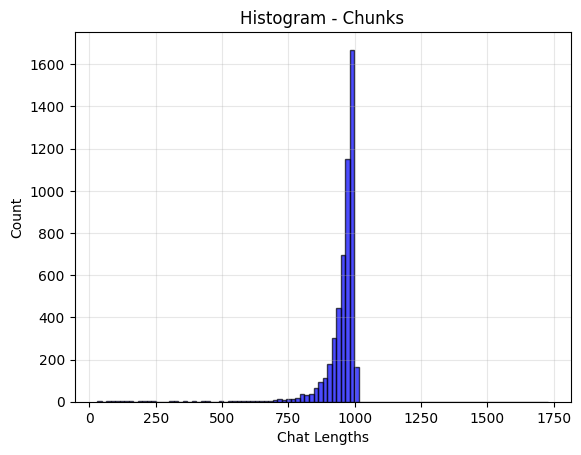

In [18]:
# Quick histogram
import matplotlib.pyplot as plt
import numpy as np
chunk_df['chunk_len'] = chunk_df['chunk_text'].apply(len)

plt.hist(chunk_df['chunk_len'],bins=100, alpha=0.7, color='blue', edgecolor='black')
plt.xlabel('Chat Lengths')
plt.ylabel('Count')
plt.title('Histogram - Chunks')
plt.grid(True, alpha=0.3)
plt.show()

In [49]:
chunk_df.to_csv('data/processed_data/whatsapp_chunks_semantic.csv')